# Import Necessary Libraries
all the necessary libraries has been imported.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

reading the 'weight-height.csv' file

In [2]:
df = pd.read_csv('/kaggle/input/datasets/kingshukdatta18/weight-height-dataset/weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


# Analyzing the dataset
The dataset has 8555 rows / records and 3 columns / features. There is no "null" / "NaN" values present. There is also no "duplicated" values.

In [3]:
df.shape

(8555, 3)

In [4]:
# checking if there is any null values
df.isna().sum()

Gender    0
Height    0
Weight    0
dtype: int64

In [5]:
# checking if there are any duplicated values
df.duplicated().sum()

np.int64(0)

In [6]:
# checking the information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8555 entries, 0 to 8554
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  8555 non-null   object 
 1   Height  8555 non-null   float64
 2   Weight  8555 non-null   float64
dtypes: float64(2), object(1)
memory usage: 200.6+ KB


In [7]:
# checking the description
df.describe()

,Height,Weight
count,8555.000000,8555.000000
mean,66.809925,165.632735
std,3.851454,32.043922
min,54.616858,65.780000
25%,63.957684,139.876803
50%,66.985923,168.521567
75%,69.604427,190.666305
max,80.450000,269.989698


In [8]:
# creating the label encoder object
le = LabelEncoder()

In [9]:
#  encoding the target variable
df["Gender"] = le.fit_transform(df["Gender"])
df.head()

,Gender,Height,Weight
0,1,73.847017,241.893563
1,1,68.781904,162.310473
2,1,74.110105,212.740856
3,1,71.730978,220.042470
4,1,69.881796,206.349801


In [10]:
# corelation matrix
df.corr()

,Gender,Height,Weight
Gender,1.000000,0.682524,0.790208
Height,0.682524,1.000000,0.922975
Weight,0.790208,0.922975,1.000000


# Visualization

<Axes: >

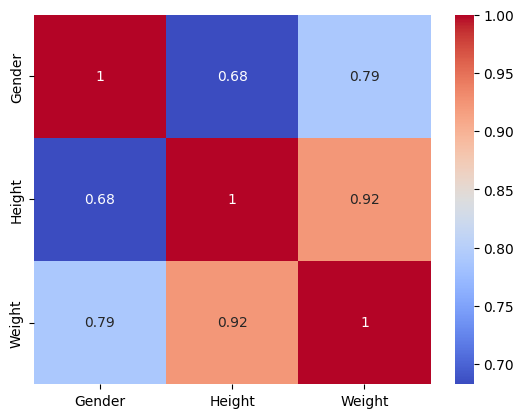

In [11]:
# Heatmap of the correlation matrix
sns.heatmap(df.corr(), annot=True,cmap='coolwarm')

In [12]:
# checking the distribution of the target variable
df["Gender"].value_counts()

Gender
1    5000
0    3555
Name: count, dtype: int64

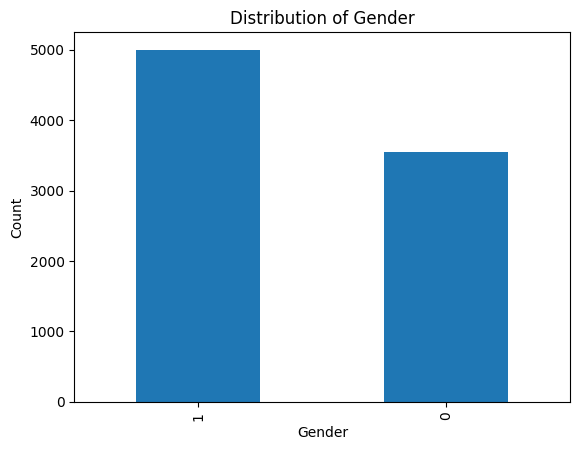

In [13]:
df["Gender"].value_counts().plot(kind="bar")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Distribution of Gender")
plt.show()

<Axes: xlabel='Height', ylabel='Count'>

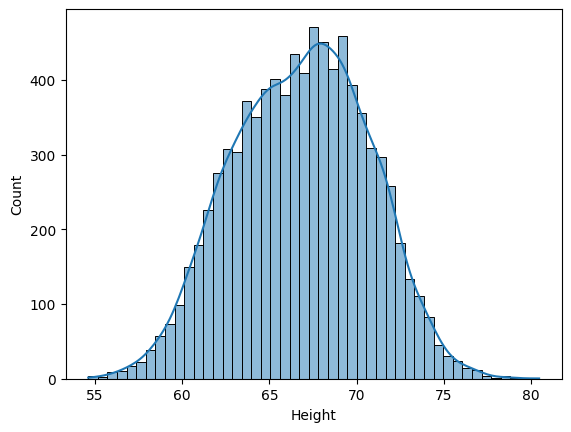

In [14]:
# checking the distribution of the height variable
sns.histplot(x = df["Height"], kde=True)

<Axes: xlabel='Weight', ylabel='Count'>

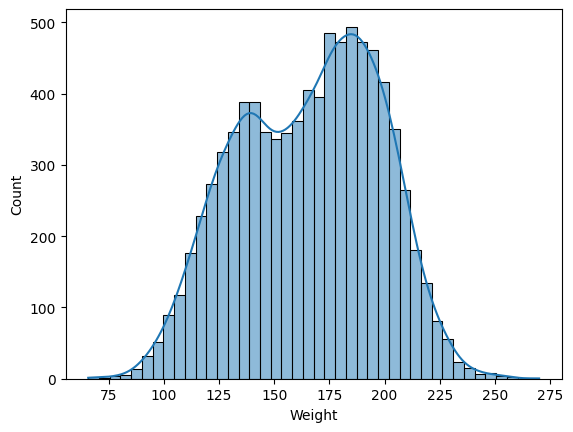

In [15]:
# checking the distribution of the weight variable
sns.histplot(x = df["Weight"], kde=True)

<Axes: ylabel='Height'>

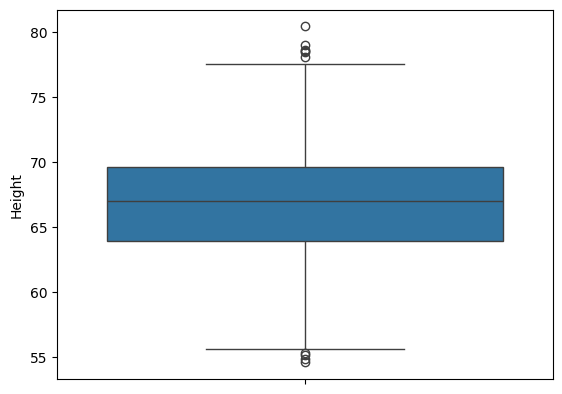

In [16]:
# checking the outliers of the height variable
sns.boxplot(df["Height"])

<Axes: ylabel='Weight'>

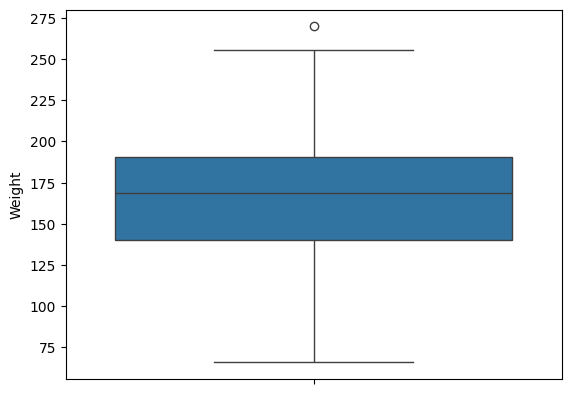

In [17]:
# checking the outliers of the weight variable
sns.boxplot(df["Weight"])

# Remove Outliers
to remove outliers we will create a function that will do the cleaning.

In [18]:
def outlier_removal(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [19]:
new_df = outlier_removal(df, "Height")

<Axes: ylabel='Height'>

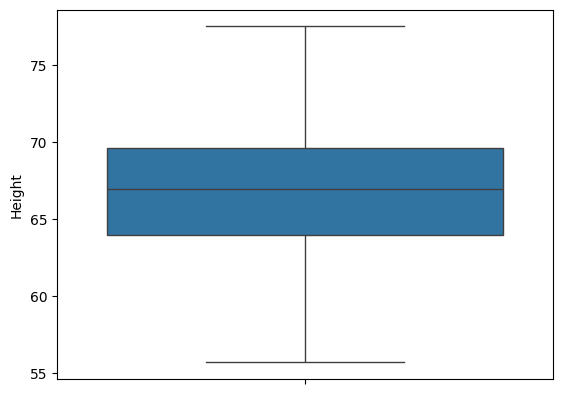

In [20]:
# there are no visible outliers in the height variable
sns.boxplot(new_df["Height"])

In [21]:
new_df = outlier_removal(new_df, "Weight")

<Axes: ylabel='Weight'>

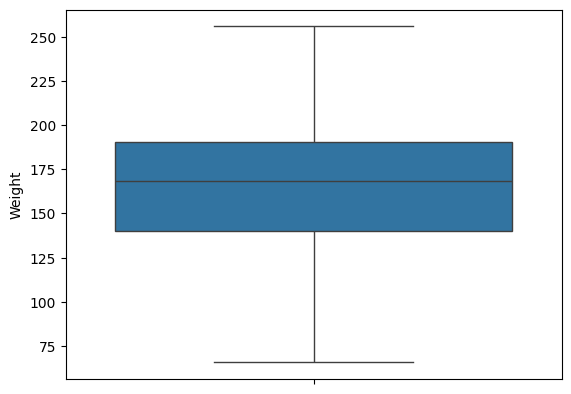

In [22]:
# there are no visible outliers in the weight variable
sns.boxplot(new_df["Weight"])

In [23]:
new_df.head(5)

,Gender,Height,Weight
0,1,73.847017,241.893563
1,1,68.781904,162.310473
2,1,74.110105,212.740856
3,1,71.730978,220.042470
4,1,69.881796,206.349801


# Seperation
we are now seperating features and output columns to two different variables.

In [24]:
# separating the features to x
x = new_df.iloc[:, 1:]
x.head()

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


In [25]:
# separating the target variable to y
y = new_df.iloc[:, 0]
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Gender, dtype: int64

In [26]:
# checking the type of x and y
type(x), type(y)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

# Train-Test-Split
here the working on a model begins.

In [27]:
# parameter optimization
score = 0
index = 0
for i in range(15, 43):
  xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.1, random_state=i)
  lr = LogisticRegression()
  
  lr_model = lr.fit(xtrain, ytrain)
  currentScore = lr_model.score(xtrain, ytrain)
    
  if currentScore > score:
    score = currentScore
    index = i
print(f"the Highest score is {score} for {index}")

the Highest score is 0.9191157347204161 for 27


In previous block, we have iterated random state value through for loop to find which random state value will give the highest score

In [28]:
# splitting the dataset into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=27)

In [29]:
# checking the shape of xtrain, xtest, ytrain, ytest
xtrain.shape, xtest.shape, ytrain.shape, ytest.shape

((6836, 2), (1709, 2), (6836,), (1709,))

In [30]:
ytest.value_counts()

Gender
1    1025
0     684
Name: count, dtype: int64

# Model Implementation

In [31]:
# creating the logistic regression model
logis = LogisticRegression()

In [32]:
# fitting the model to the training data
model = logis.fit(xtrain, ytrain)

In [33]:
print(model.score(xtrain, ytrain))
print(model.score(xtest, ytest))

0.9218841427735518
0.9057928613224108


# Checking with Linear Regression approach


In [34]:
lr = LinearRegression()
lr_model = lr.fit(xtrain, ytrain)
print(lr_model.score(xtrain, ytrain))
print(lr_model.score(xtest, ytest))

0.6466720079300998
0.611616469354864


| Criteria     | Linear Regression Scores     | Logistic Regression  scores   |
| :---:         | :---:          | :---:          |
| xtrain, ytrain | 0.6466720079300998 ~ 64.67% | 0.9218841427735518 ~ 92.88%|
| xtest, ytest| 0.611616469354864 ~ 61.16% | 0.9057928613224108 ~ 90.58%|

we can see significant downfall between 2 models. So we can say that "Logistic Regression" is the best approach.

In [35]:
# prediction finding
y_pred = model.predict(xtest)
y_pred

array([1, 0, 0, ..., 0, 1, 1])

In [36]:
xtest.head()

,Height,Weight
3254,69.907081,183.280807
6032,63.442212,134.801974
1970,66.361636,153.321686
7579,60.305218,107.978309
5240,61.456504,119.548497


In [37]:
ytest.head(5)

3254    1
6032    0
1970    1
7579    0
5240    0
Name: Gender, dtype: int64

In [38]:
ytest.tail(5)

2917    1
114     1
6704    0
4852    1
2131    1
Name: Gender, dtype: int64

# Checking Accuracy Score

In [39]:
# evaluating the model using accuracy score
ac = accuracy_score(ytest, y_pred)
print(f"the accuracy score is {ac}")

the accuracy score is 0.9057928613224108


In [40]:
# generating classification report
class_re = classification_report(ytest, y_pred)

In [41]:
print(class_re)

              precision    recall  f1-score   support

           0       0.89      0.88      0.88       684
           1       0.92      0.92      0.92      1025

    accuracy                           0.91      1709
   macro avg       0.90      0.90      0.90      1709
weighted avg       0.91      0.91      0.91      1709



In [42]:
# Confusion matrix
cm = confusion_matrix(ytest, y_pred)
cm

array([[600,  84],
       [ 77, 948]])

<Axes: >

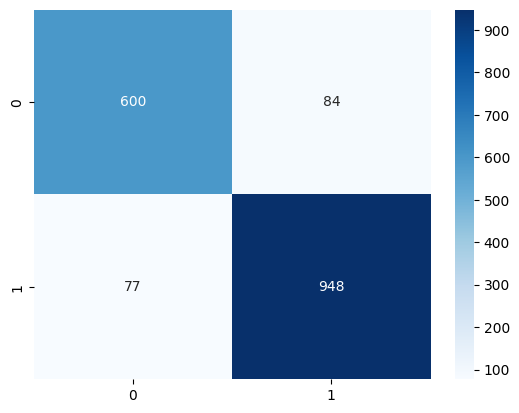

In [43]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

In [44]:
#roc_auc_score(ytest, y_pred)
roc = roc_auc_score(ytest, y_pred)
roc

np.float64(0.9010355156183142)

based on the class probabilities the model determines which gender will it be.

In [45]:
# to find the class probabilities
y_predict_probability = model.predict_proba(xtest)
y_predict_probability

array([[0.05411729, 0.94588271],
       [0.96832437, 0.03167563],
       [0.77597558, 0.22402442],
       ...,
       [0.83427759, 0.16572241],
       [0.00675392, 0.99324608],
       [0.00263835, 0.99736165]])

In [46]:
y_pred = model.predict([[170, 65]])
y_pred

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

# Model Saving

In [47]:
import pickle
pickle.dump(model, open("gender_predictor_based_on_weight_height.pkl", "wb"))